# Probabilistic error cancellation (PEC) with Twirled Readout Error eXtinction (TREX)

[PEC](https://arxiv.org/pdf/1612.02058) is a technique for mitigating quantum noise in observable expectation value calculations, that allows comupting an unbiased estimate of the expectation values. It works by executing an ensemble of noisy circuits, injected with the inverse of a learned noise model. The noise model is approximated to a Pauli channel by using Pauli twirling (also known as [randomized compiling](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.94.052325)). Such noise model can be learned efficiently and be mitigated using PEC (see [Probabilistic error cancellation with sparse Pauli-Lindblad models on noisy quantum
processors](https://arxiv.org/pdf/2201.09866) for more details).

<img src="../images/pec.png" width="800"/>

[TREX](https://arxiv.org/pdf/2012.09738) is a technique for mitigation measurement errors for the estimation of Pauli observable expectation values. It realy on measurement twirling (randomaly injecting an `X` gate before the measurement and flipping the measured result), which has the effect of diagonalizing the readout-error transfer matrix, making it easy to invert. A rescaling term from the diagonal noise channel is learned by measurement twirled calibration circuits initialized in the zero state.

<img src="../images/measurement_twirling.png" width="300"/>

In this guide we will show how to use PEC method to mitigate gates noise and how to combine it with TREX method to mitigate also measurement noise in estimating expectation values of observables.

The workflow will be as follows:
1. Specify a circuit and observable
2. Compute exact expectation values using Qiskit's statevector simulator
3. Compute noisy, unmitigated expectation values
4. Learn the noise of the entangling layers with qiskit-noise-learning
5. Prepare a PEC+TREX program and add a TREX calibration circuit to it
6. Compare the mitigated expectation values

### Specify a circuit and observable

In this guide we will prepare a mirror circuit of a Trotterized time evolution of a linear line transverse-field Ising model on ``8`` qubits. By mirroring the circuit we cancel the circuit unitary to form an identity circuit. This allows us to easily compute the ideal expectation value of each observable. In addition, the mirroring doubles the depth of the circuit, which in turn doubles the effect of the noise. 

We will choose an angle of $\theta= \frac{\pi}{2}$ to keep all the gates in the circuit from the Clifford group, allowing faster simulation using `stabilizer` simulator.

Visualization of 1 mirrored Trotter step


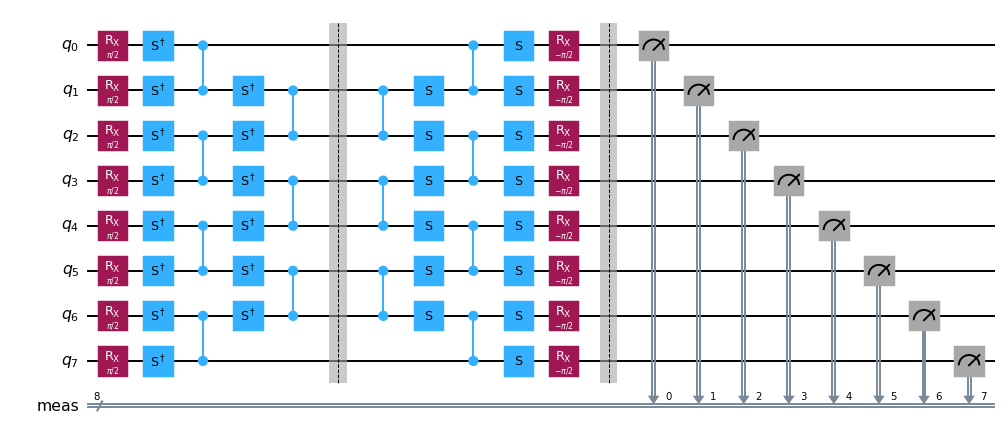

In [1]:
import warnings

import numpy as np
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

warnings.filterwarnings("ignore")


def construct_ising_circuit(
    num_qubits: int, num_trotter_steps: int, rx_angle: float, barrier: bool = True
) -> QuantumCircuit:
    circuit = QuantumCircuit(num_qubits)

    for _step in range(num_trotter_steps):
        circuit.rx(rx_angle, range(num_qubits))
        if barrier:
            circuit.barrier()
        for first_qubit in (1, 2):
            for idx in range(first_qubit, num_qubits, 2):
                # equivalent to Rzz(-pi/2):
                circuit.sdg([idx - 1, idx])
                circuit.cz(idx - 1, idx)
        if barrier:
            circuit.barrier()

    return circuit


def mirror_circuit(circuit: QuantumCircuit) -> QuantumCircuit:
    mirror_circ = circuit.copy_empty_like()
    mirror_circ.compose(circuit, inplace=True)
    mirror_circ.barrier()
    mirror_circ.compose(circuit.inverse(), inplace=True)
    mirror_circ.measure_active()
    return mirror_circ


# define observables
num_qubits = 8
observables = [
    SparsePauliOp("I" * ((num_qubits - 1) - q) + "Z" + "I" * q) for q in range(num_qubits)
]

# Instantiate circuit
num_trotter_steps = 5
rx_angle = np.pi / 2

circuit = construct_ising_circuit(num_qubits, num_trotter_steps, rx_angle, barrier=False)
mirrored_circuit = mirror_circuit(circuit)
print("Visualization of 1 mirrored Trotter step")
mirror_circuit(construct_ising_circuit(num_qubits, 1, rx_angle, barrier=False)).draw(
    "mpl", scale=0.7
)

### Compute noisy, unmitigated expectation values

A ``QuantumProgram`` contains a quantum circuit and a samplex in a format suitable for the Executor primitive. `MitigationTask.prepare` builds a ``QuantumProgram`` from the circuit, the observables and the parameter values, and boxes the circuit with the given boxing options. We set the ``measure_annotations`` boxing option to ``"change_basis"`` which rotates the measurements into the required bases, and we add ``add_tags: "unique_box"`` so the simulator can map a noise model onto the boxes of the circuit. The program is Pauli twirled by default, which on hardware turns coherent noise into the Pauli noise that the mitigation methods assume. `num_randomizations` sets how many twirled instances of each circuit are sampled and `shots_per_randomization` sets how many shots each instance receives, so their product is the shot budget per circuit.

A user with QPU access would execute the program with an `Executor` built from a backend of the `QiskitRuntimeService`. Here we pass an `AerSimulator` to the `Executor`, which runs the program locally, and use its `layer_noise_model` simulator option to inject a random Pauli-Lindblad noise model on every layer of entangling gates, generated with `random_pauli_lindblad_noise` from `qiskit-mitigation` with an error per layered gate (EPLG) of ``0.003``, typical of current Heron QPUs.

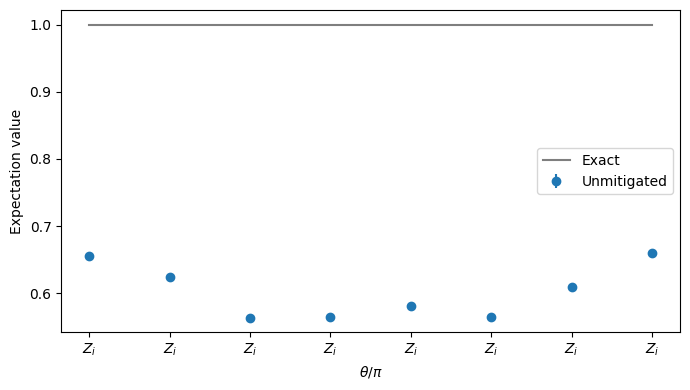

In [2]:
import matplotlib.pyplot as plt
from qiskit.quantum_info import PauliLindbladMap, pauli_basis
from qiskit.transpiler import PassManager
from qiskit_aer import AerSimulator
from qiskit_mitigation import MitigationTask, find_combined_unique_layers
from qiskit_noise_learning.aer_executor import AerExecutor
from qiskit_noise_learning.aer_executor.insert_noise_pass import InsertNoisePass
from samplomatic import Tag
from samplomatic.utils import get_annotation


def generate_random_pauli_lindblad_noise(
    layers,
    num_qubits: int,
    noise_scale: float = 1e-3,
    readout_noise_scale: float = 3e-2,
    seed: int | None = None,
) -> tuple[dict[str, PauliLindbladMap], dict[str, PauliLindbladMap]]:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    gate_noise_dict = {}
    readout_noise_dict = {}
    for layer in layers:
        layer_instructions = layer.operation.params[0]
        contain_measurement = any(inst.name.startswith("measure") for inst in layer_instructions)
        layer_id = (
            get_annotation(layer.operation, Tag).ref
            if get_annotation(layer.operation, Tag)
            else None
        )
        if layer_id is None:
            continue
        if contain_measurement:
            rng = np.random.default_rng(seed=seed)
            rates = rng.random(num_qubits) * readout_noise_scale
            layer_noise = PauliLindbladMap.from_sparse_list(
                [("X", [q], rate) for q, rate in enumerate(rates)],
                num_qubits=num_qubits,
            )
            readout_noise_dict[layer_id] = layer_noise
        else:
            edges = [
                (inst.qubits[0]._index, inst.qubits[1]._index) for inst in layer_instructions
            ]  # extract the edges of the layer

            basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
            rng = np.random.default_rng(seed=seed)
            rates = rng.random(len(basis_paulis)) * noise_scale

            layer_noise = PauliLindbladMap.from_sparse_list(
                [
                    (pauli.to_label(), edge, rate)
                    for pauli, rate in zip(basis_paulis, rates, strict=True)
                    for edge in edges
                ],
                num_qubits=num_qubits,
            )
            gate_noise_dict[layer_id] = layer_noise
    return gate_noise_dict, readout_noise_dict


def add_readout_noise(program, readout_noise_map):
    readout_noise_model = next(iter(readout_noise_map.values()))
    for item in program.items:
        readout_tag = item.circuit[-1].label[-4:]  # extract the readout layer tag from the circuit
        readout_noise_map[readout_tag] = readout_noise_model
        item.circuit = PassManager(
            [InsertNoisePass(noise_dict=readout_noise_map, noise_after=False)]
        ).run(item.circuit)


num_randomizations = 250
shots_per_randomization = 64

boxing_options = {"add_tags": "unique_box"}

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([mirrored_circuit], custom_boxing_options=boxing_options)
layer_noise_model, readout_noise_map = generate_random_pauli_lindblad_noise(
    box_layers, num_qubits, seed=42
)

# a local noisy simulator in place of a QPU backend
# noisy_executor = Executor(
#     AerSimulator(method="stabilizer"), options={"simulator": {"layer_noise_model": layer_noise_model}}
# )
noisy_executor = AerExecutor(
    qasm_simulator=AerSimulator(method="stabilizer"), noise_dict=layer_noise_model
)

task = MitigationTask()
program = task.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)
# For the simulation - we inject readout noise to the circuits of the program
add_readout_noise(program, readout_noise_map)

unmitigated_res = task.postprocess(noisy_executor.run(program).result())

x_vals = np.array(range(num_qubits))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, [1] * len(x_vals), "k-", alpha=0.5, label="Exact")
ax.errorbar(
    x_vals,
    unmitigated_res.data.evs,
    unmitigated_res.data.stds,
    fmt="o",
    label="Unmitigated",
)

x_tick_labels = [r"$Z_{ {i} }$" for i in range(num_qubits)]
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel("Expectation value")
ax.legend()
ax.set_xticks(x_vals, x_tick_labels)
plt.tight_layout()
plt.show()

### Learn the noise of the entangling layers with qiskit-noise-learning

PEC starts by learning the twirled noise model of each layer of entangling gates in the circuit. We assume a Markovian noise model, therefore only the noise model of each unique layer of entangling gates should be learned, as the depth of the circuit is assumed to not affect the noise channel of a given entangling layer. The circuit used in this guide can be split into 2 unique layers. Designing circuits to have a minimal set of unique entangling layers is important if one wants to learn a noise model, as the unique layers must be learned independently. If one has too many unique layers in their circuit, noise learning can become infeasible due to the sampling cost of learning many layers.

We use `qiskit-noise-learning` for learning the noise. The learner repeats each layer `fragment_depths` times in its learning circuits, twirls each circuit `num_randomizations` times, and fits the decay of the measured fidelities to a Pauli-Lindblad model. These parameters can effect the accuracy of the learned model. more accurate the learned noise model is, the more accurate the noise cancellation will be.
Below we draw the learned noise model, with the two layers merged into one map. Each qubit is a pie of its weight-1 X, Y and Z rates summed over the two layers, and each edge shows the learned weight-2 rates; a rate of ``3e-4`` means that error occurs on roughly 3 of every 10,000 uses of the layer.

As opposed to the gate noise model, which is required for the program preperation in order to inject the anti-noise that corresponds to the learned noise model, the mitigation of the readout noise is done in post-processing using TREX.
Therefore, the readout noise can be either executed and learned along the learning of the gates noise, or along the execution of the mitigated program. Learning the readout noise alongside the gate noise might be beneficial for leaening self-consistent noise model (see [Disambiguating Pauli noise in quantum computers](https://arxiv.org/pdf/2505.22629) for example). In cases where the gate noise and the readout noise are separated in the noise model, it is suggested to learn the readout noise along the execution of the mitigated program, to avoid as much as possible drifts in the noise between the learned time and the execution. In this guide we will learn the readout noise along the execution of the mitigated program using TREX calibration circuit.

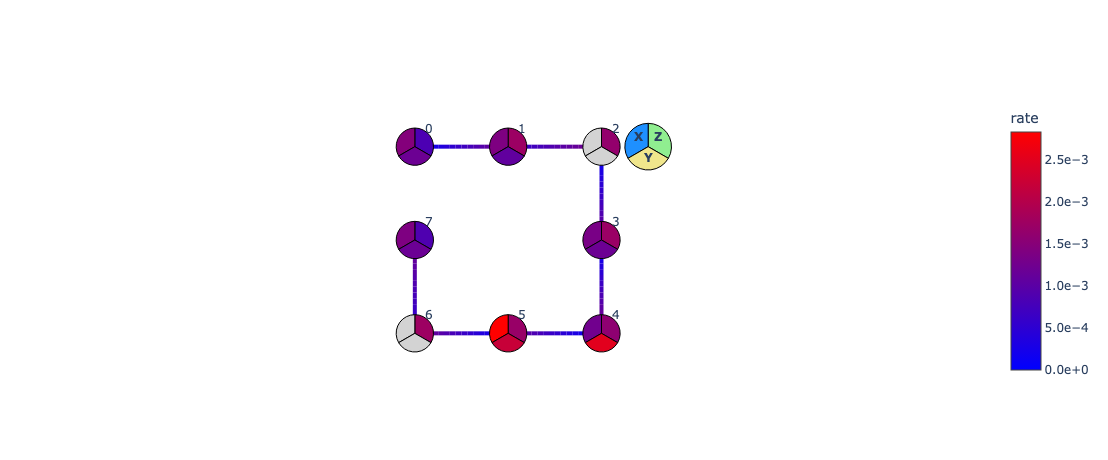

In [6]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliList
from qiskit_ibm_runtime.results import LayerError, PauliLindbladError
from qiskit_ibm_runtime.visualization.embeddings import Embedding
from qiskit_mitigation import PEC
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner
from samplomatic import InjectNoise

line_coupling = [(i, i + 1) for i in range(num_qubits - 1)]
backend = GenericBackendV2(
    num_qubits=num_qubits, basis_gates=["id", "rz", "sx", "x", "cz"], coupling_map=line_coupling
)

task_pec = PEC()
# first learn only the layers PEC will inject noise into, i.e. not the measurement layer
pec_layers = [
    layer
    for layer in task_pec.find_unique_layers(mirrored_circuit, boxing_options)
    if get_annotation(layer.operation, InjectNoise)
]
layers = task_pec.find_unique_layers(mirrored_circuit, boxing_options)

learning_options = LearningOptions(
    fragment_depths=[2, 4, 8, 16], num_randomizations=200, shots_per_randomizations=64
)
learner = NoiseLearner(backend, options=learning_options, executor=noisy_executor)
learned_noise = learner.run(pec_layers).result().to_dict()  # keyed by InjectNoise reference

# Draw the learned model on the line, laid out as a line with the qubits in order.
# Composing the two layers' maps sums their rates, giving one map over all the edges.
embedding = Embedding(
    [(0, 0), (0, 2), (0, 4), (2, 4), (4, 4), (4, 2), (4, 0), (2, 0)], line_coupling
)
first, second = learned_noise.values()
learned_model = first.compose(second).simplify()
error = PauliLindbladError(
    PauliList(learned_model.get_qubit_sparse_pauli_list_copy().to_pauli_list()), learned_model.rates
)
fig = LayerError(circuit, list(range(num_qubits)), error).draw_map(
    embedding, radius=0.4, height=460, width=620
)
fig.update_traces(
    marker={
        "cmin": 0,
        "cmax": max(learned_model.rates),
        "colorbar": {"tickformat": ".1e", "title": "rate"},
    },
    selector={"mode": "markers"},
)
fig.show()

### Prepare a combined PEC and TREX program

Here we prepare both a `TREX` and a `PEC` tasks, and add the trex task as a variable to the PEC task. This ensures that all the reiquired properties needed for TREX mitigation are added to the PEC mitigated item (like measurement twirling). The injected noise is sampled once per randomization, so the statistical error of PEC is controlled by the number of randomizations rather than the shots per randomization; we therefore use many randomizations with few shots each, keeping the total number of shots the same as for the unmitigated program.

We add to the program also the TREX calibration circuit, in order to learn the readout noise along the execution of the program. The TREX calibration circuit is very shallow, making additinal randomizations for this item to be relatively cheap, allowing learning the readout noise more accuratly.

In [21]:
from qiskit_mitigation import TREX

trex = TREX()

program_pec = task_pec.prepare(
    circuit=mirrored_circuit,
    observables=observables,
    parameters=None,
    num_randomizations=1000,
    shots_per_randomization=16,
    custom_boxing_options=boxing_options,
    trex=trex,
    noise_maps=learned_noise,  # PEC option
    noise_gain=0,  # PEC option
    max_sampling_overhead=100,  # PEC option
)
program_pec = trex.prepare(
    num_randomizations=1000, quantum_program=program_pec, custom_boxing_options=boxing_options
)

# For the simulation - we inject readout noise to the circuits of the program
add_readout_noise(program_pec, readout_noise_map)

### Examing shot overhead, executing the program and post-process
PEC returns an unbiased expectation value estimation, with a cost of large shot overhead. The required shot overhead can be approximated by calculating the circuit gamma factor, which reflects the effect of the learned noise model on the circuit. The number of randomization of the PEC task is scaled by default by the approximated amount of shots overheaed required to have an unbiased estimation (~$\gamma^2$). In order to avoid this automatic scale, one can set the parameter `scale_randomizations_by_gamma` to `False`. The shots overhead is capped by the `max_sampling_overhead` parameter.

It is advised to inspect the number of shots required by PEC to reach unbiased estimation before execution, to reason whether this amount is affordable, as this scale is exponential in the noise rates and depth of the circuit.

In [22]:
print(f"The circuit calculated gamma is: {task_pec.gamma}")
print(f"The circuit show overhead is ~{task_pec.gamma**2}")

The circuit calculated gamma is: 3.5618056004223235
The circuit show overhead is ~12.68645913519983


In [23]:
job_pec_results = noisy_executor.run(program_pec).result()

# post-processing
pec_res = task_pec.postprocess(job_pec_results)
# In order to post process the results without TREX, we call `postprocess` again, but instead of the default options we
# pass only the PEC item result and the `measure_noise_data` as `None`
pec_without_trex_res = task_pec.postprocess(
    job_pec_results[task_pec._program_item_index], measure_noise_data=None
)

### Compare the mitigated expectation values

Here we plot the expectation value of each observable. PEC+TREX recovers the exact expectation values within its error bars, while the unmitigated result is biased well below it.

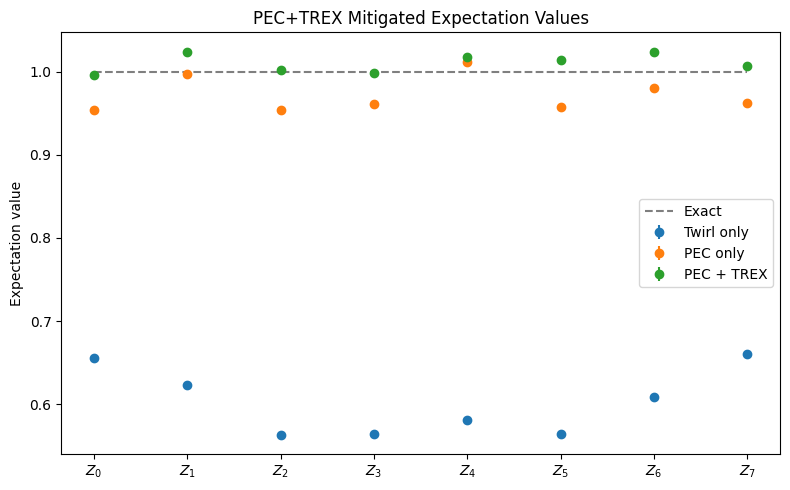

In [24]:
x = np.array(range(num_qubits))
x_tick_labels = [r"$Z_{ {i} }$" for i in range(num_qubits)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x,
    unmitigated_res.data.evs,
    unmitigated_res.data.stds,
    fmt="o",
    label="Twirl only",
)
ax.errorbar(
    x,
    pec_without_trex_res.data.evs,
    pec_without_trex_res.data.stds,
    fmt="o",
    label="PEC only",
)
ax.errorbar(
    x,
    pec_res.data.evs,
    pec_res.data.stds,
    fmt="o",
    label="PEC + TREX",
)

ax.plot(x, [1] * len(x), "--", color="black", alpha=0.5, label="Exact")

tick_labels = [f"$Z_{ {i} }$" for i in range(num_qubits)]
ax.set_xticks(x, tick_labels)

ax.set_ylabel("Expectation value")
ax.legend()
ax.set_title("PEC+TREX Mitigated Expectation Values")
plt.tight_layout()
plt.show()